# Sprint 3 — Modelo para Baseline e Detecção de Anomalias

**Challenge Forzy · FIAP · Manutenção preditiva de motores elétricos**

Este notebook executa o pipeline completo, documenta as decisões metodológicas e
apresenta os resultados usados na entrega. Todos os números são recalculados a partir
de `data/motor.db`; nenhum serviço externo é necessário.

In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.run_sprint3 import run_pipeline
from src.anomaly_service import build_agent_payload
from src.data_utils import FEATURES, TIPOS_FALHA

result = run_pipeline(save_artifacts=False)
metrics = result.metrics
scored = result.scored
print(f"Pipeline executado: {len(scored):,} janelas; melhor detector por PR-AUC = {metrics['best_anomaly_model']}")

Pipeline executado: 5,900 janelas; melhor detector por PR-AUC = statistical


## 1. Descrição do problema de anomalias

Consideramos **normal** uma janela compatível com o baseline do próprio motor e
**anômala** uma janela cujo score supera o threshold calibrado na validação.
A abordagem é **semissupervisionada**: os rótulos selecionam períodos confiáveis e
avaliam resultados, mas os detectores aprendem apenas o padrão normal. Isso é relevante
porque o banco só rotula a falha depois que a degradação já ganhou intensidade.

In [2]:
pd.DataFrame({
    "Definição": ["Janela", "Alerta", "Persistência", "Antecipação"],
    "Regra": ["30 leituras / 30 minutos", "score > threshold", "3 janelas consecutivas", "até 60 min antes do evento"],
})

,Definição,Regra
0,Janela,30 leituras / 30 minutos
1,Alerta,score > threshold
2,Persistência,3 janelas consecutivas
3,Antecipação,até 60 min antes do evento


## 2. Descrição dos dados da Forzy

O SQLite reúne cadastro e telemetria sintética de 20 motores. Há uma leitura por minuto
de rotação, vibração, temperatura e corrente; `falha` registra normalidade ou uma das
três falhas conhecidas. O período total é curto (25 horas por motor), uma limitação para
generalização industrial.

In [3]:
data_summary = pd.Series(metrics["data"], name="valor")
display(data_summary)
display(pd.DataFrame({"sensor": FEATURES}))

motors                                                                      20
readings                                                                 30000
windows                                                                   5900
start                                                      2026-01-01T00:00:00
end                                                        2026-01-02T00:59:00
missing_values                                                               0
duplicate_motor_timestamps                                                   0
label_counts                      {'0': 26291, '1': 1205, '2': 1718, '3': 786}
partition_windows             {'train': 3540, 'test': 1475, 'validation': 885}
Name: valor, dtype: object

,sensor
0,rotacao_rpm
1,vibracao_mm_s
2,temperatura_c
3,corrente_a


## 3. Análise exploratória dos dados

A EDA compara distribuições normal/falha, evolução temporal e correlações. Os níveis
normais diferem por motor, enquanto episódios rotulados formam rampas persistentes.
Não há valores ausentes nem timestamps duplicados por motor.

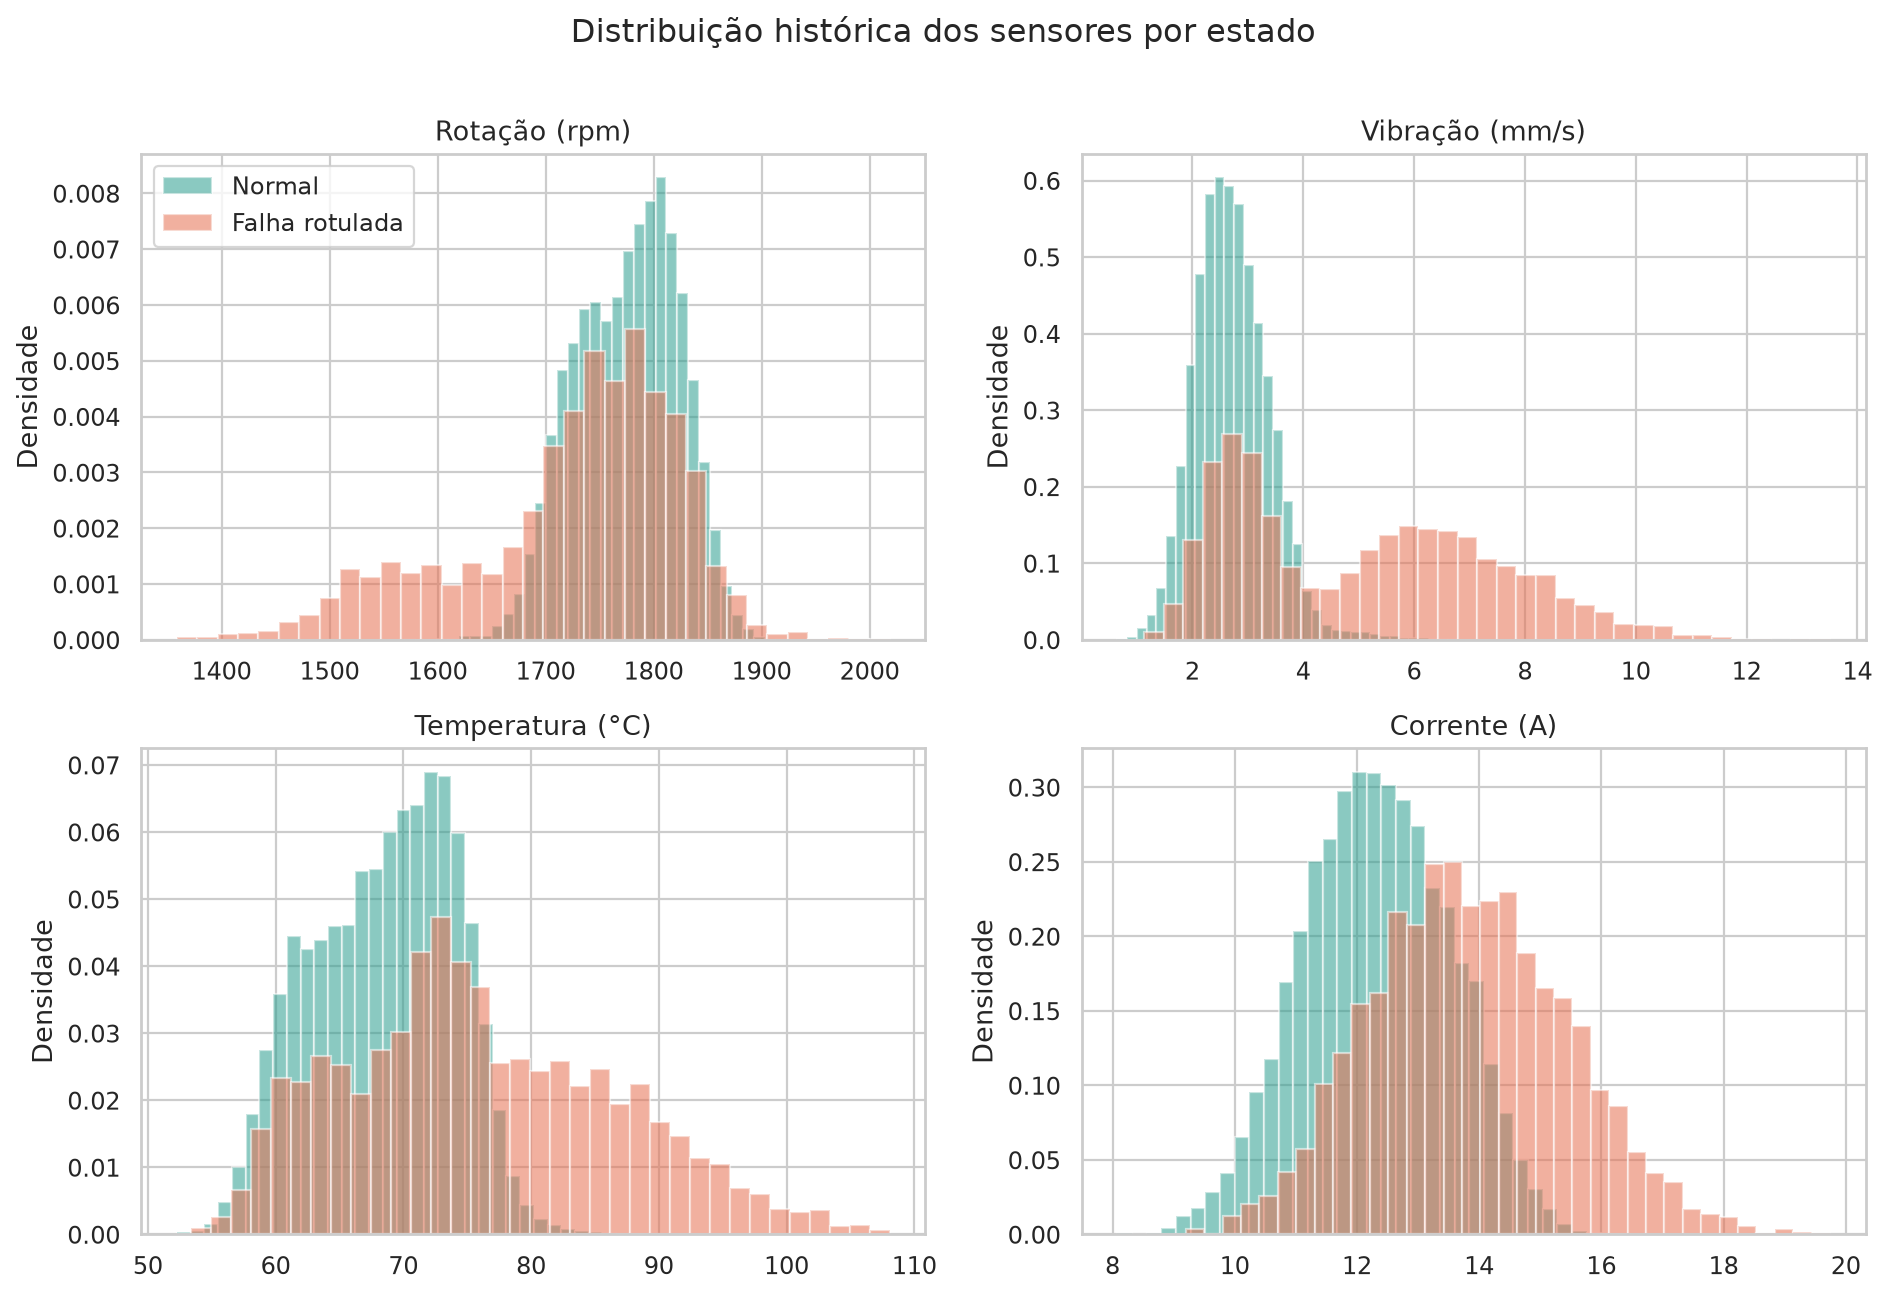

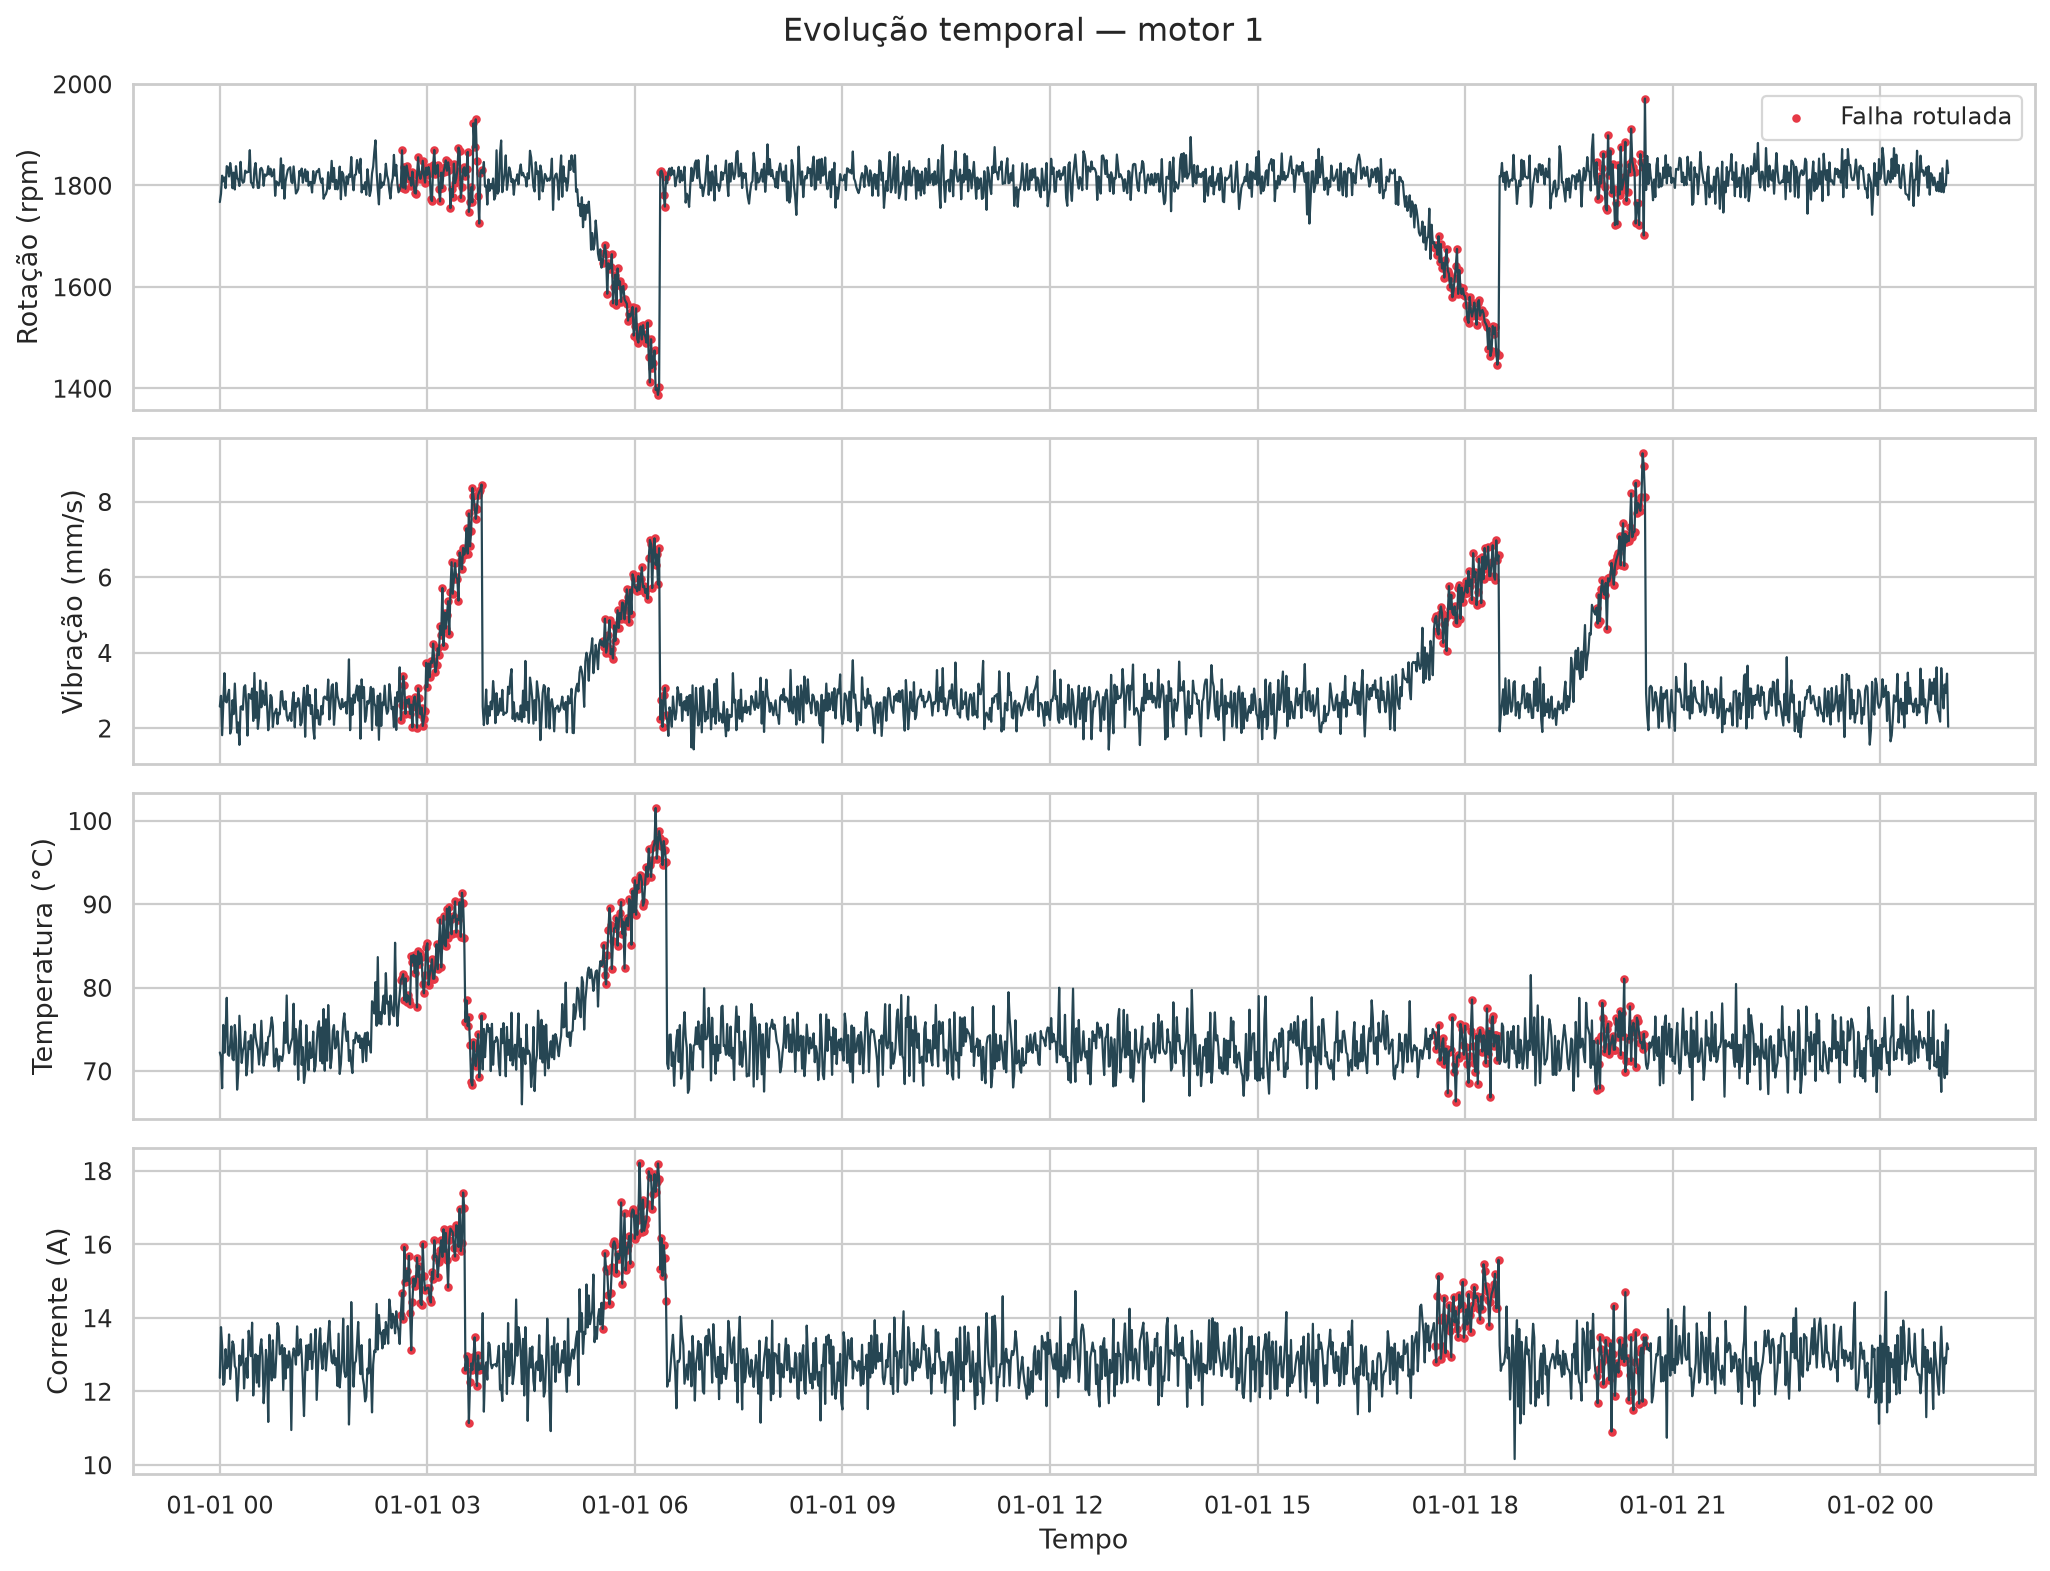

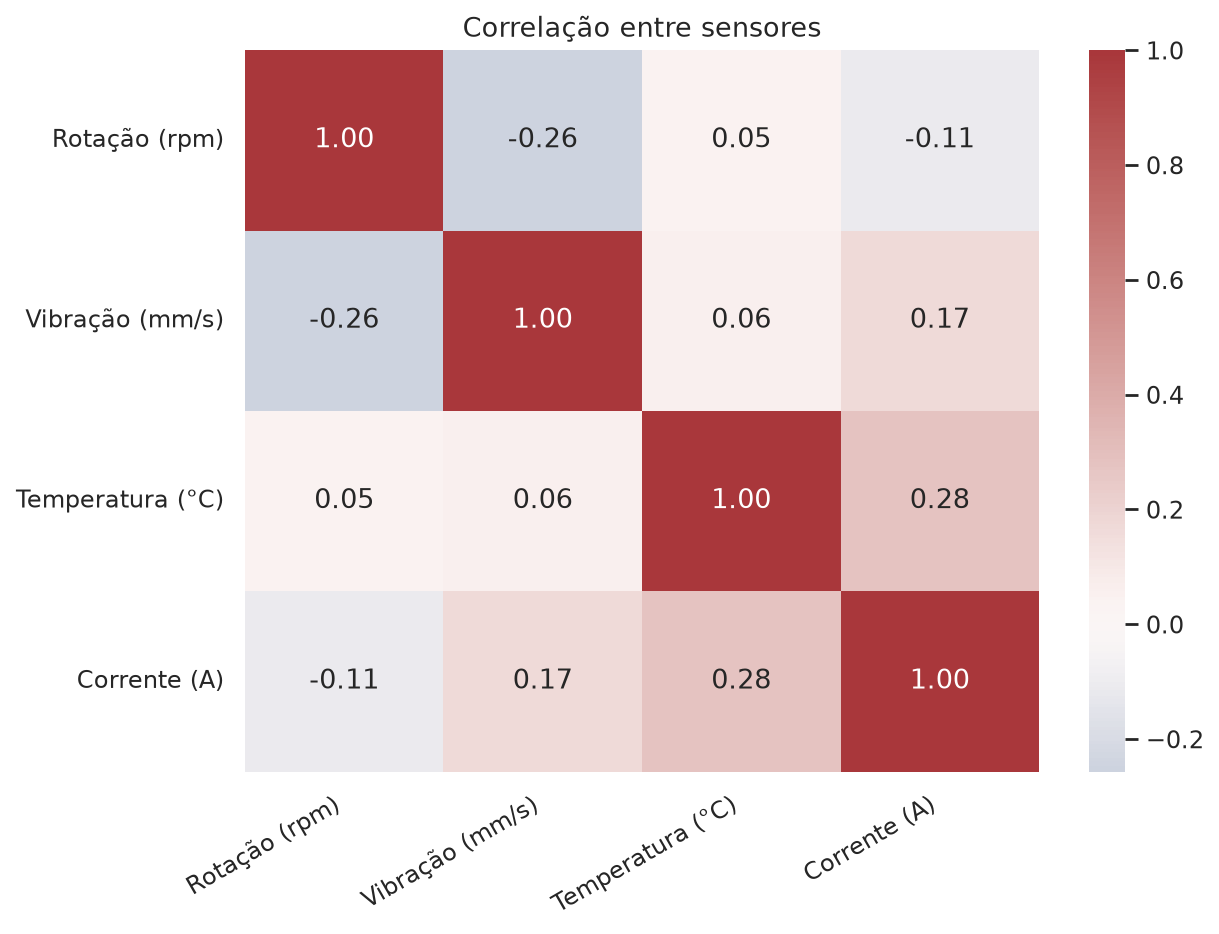

In [4]:
for name in [
    "s3_01_distribuicao_sensores.png",
    "s3_02_evolucao_temporal.png",
    "s3_03_correlacao.png",
]:
    display(Image(filename=str(ROOT / "figuras" / name)))

## 4. Definição do baseline operacional

Cada motor é calibrado pelas primeiras 30 leituras usando mediana e IQR. O baseline
estatístico calcula o maior desvio absoluto médio entre sensores. Isolation Forest e
Autoencoder recebem representações normalizadas; cada threshold é o percentil 99 dos
scores normais da validação, sem consultar o teste.

In [5]:
pd.DataFrame({
    "modelo": list(metrics["thresholds"]),
    "threshold": list(metrics["thresholds"].values()),
    "fonte": metrics["threshold_source"],
})

,modelo,threshold,fonte
0,statistical,1.204942,validation_normal_guard_clean
1,isolation_forest,0.525067,validation_normal_guard_clean
2,autoencoder,0.951250,validation_normal_guard_clean


## 5. Preparação dos dados

O split é feito por motor: treino, validação e teste são ativos diferentes. Janelas de
treino precisam ser totalmente normais e ficar 30 minutos afastadas de qualquer falha
rotulada. Janelas nunca atravessam motores nem lacunas temporais.

In [6]:
display(pd.Series(metrics["split"], name="motores"))
display(pd.Series(metrics["window_config"], name="valor"))
print("Shape sequencial:", result.prepared.sequences.shape)
print("Shape de features agregadas:", result.prepared.summaries.shape)
print("Janelas usadas no fit/threshold:", metrics["fit_counts"])

train_motors         [4, 5, 6, 7, 9, 11, 12, 14, 17, 18, 19, 20]
validation_motors                                     [3, 8, 13]
test_motors                                   [1, 2, 10, 15, 16]
Name: motores, dtype: object

window_size         30
stride               5
calibration_size    30
guard_size          30
Name: valor, dtype: int64

Shape sequencial: (5900, 30, 4)
Shape de features agregadas: (5900, 24)
Janelas usadas no fit/threshold: {'train': 2407, 'validation_threshold': 556}


## 6. Treinamento do modelo de anomalias

O **Isolation Forest** usa 24 estatísticas temporais (média, desvio, mínimo, máximo,
último valor e inclinação por sensor). O **Autoencoder denso** recebe 120 entradas
(30 × 4), comprime para 16 neurônios e reconstrói a sequência. Seu MAE de reconstrução
é o score; erro alto indica padrão diferente do normal aprendido.

In [7]:
pd.Series(metrics["training_info"], name="valor")

threshold_quantile         0.990000
autoencoder_iterations    46.000000
autoencoder_loss           0.392965
Name: valor, dtype: float64

## 7. Avaliação dos resultados

Avaliamos precision, recall, F1, ROC-AUC, PR-AUC, falsos positivos e matriz de confusão.
Também medimos recall por evento e antecedência da primeira detecção persistente. PR-AUC
é especialmente útil porque as anomalias são minoritárias.

In [8]:
metric_columns = ["precision", "recall", "f1", "pr_auc", "roc_auc", "false_positive_rate"]
window_table = pd.DataFrame(metrics["window_metrics"]).T[metric_columns]
event_table = pd.DataFrame(metrics["event_metrics"]).T
display(window_table.style.format("{:.3f}"))
display(event_table)

,precision,recall,f1,pr_auc,roc_auc,false_positive_rate
statistical,0.582,0.988,0.733,0.702,0.966,0.094
isolation_forest,0.579,0.942,0.717,0.665,0.957,0.091
autoencoder,0.605,0.924,0.731,0.537,0.947,0.080
sprint2,0.860,0.860,0.860,0.923,0.980,0.018


,events,detected_events,event_recall,anticipated_events,median_lead_minutes
statistical,19.0,19.0,1.000000,5.0,-4.0
isolation_forest,19.0,19.0,1.000000,4.0,-7.0
autoencoder,19.0,19.0,1.000000,1.0,-12.0
sprint2,19.0,16.0,0.842105,2.0,-10.5


## 8. Análise dos casos anômalos

O ranking identifica motores com maior frequência e persistência de alertas. Os erros
do Autoencoder mostram quais sensores foram mais difíceis de reconstruir; essa é uma
explicação do modelo, **não uma prova causal** da falha física.

In [9]:
display(result.motor_ranking)
display(result.sensor_ranking)
display(result.event_details.query("model == 'autoencoder'").head(10))

,motor_id,windows,labeled_anomaly_rate,alert_rate,persistent_rate,mean_score,max_score
0,1,295,0.155932,0.247458,0.220339,1.077926,5.142161
1,2,295,0.132203,0.193220,0.172881,0.834645,3.348556
2,15,295,0.122034,0.179661,0.152542,0.830089,2.957923
3,16,295,0.081356,0.142373,0.122034,0.955536,4.085514
4,10,295,0.091525,0.128814,0.108475,0.780010,2.042476


,sensor,mean_error,dominant_alert_count
0,vibracao_mm_s,2.228845,102
1,rotacao_rpm,1.956553,54
2,corrente_a,1.874082,82
3,temperatura_c,1.720723,25


,model,event_id,motor_id,fault_classes,primary_fault_class,start,end,duration_minutes,previous_end,detected,first_alert,lead_minutes,anticipated
38,autoencoder,1,1,"2,1",2,2026-01-01 02:37:00,2026-01-01 03:47:00,71,NaT,True,2026-01-01 02:49:00,-12.0,False
39,autoencoder,2,1,"2,3",3,2026-01-01 05:32:00,2026-01-01 06:27:00,56,2026-01-01 03:47:00,True,2026-01-01 05:29:00,3.0,True
40,autoencoder,3,1,3,3,2026-01-01 17:34:00,2026-01-01 18:29:00,56,2026-01-01 06:27:00,True,2026-01-01 17:34:00,0.0,False
41,autoencoder,4,1,1,1,2026-01-01 19:54:00,2026-01-01 20:36:00,43,2026-01-01 18:29:00,True,2026-01-01 20:09:00,-15.0,False
42,autoencoder,5,2,"1,3",3,2026-01-01 03:19:00,2026-01-01 04:05:00,47,NaT,True,2026-01-01 03:24:00,-5.0,False
43,autoencoder,6,2,1,1,2026-01-01 14:37:00,2026-01-01 15:16:00,40,2026-01-01 04:05:00,True,2026-01-01 14:59:00,-22.0,False
44,autoencoder,7,2,2,2,2026-01-01 15:32:00,2026-01-01 16:20:00,49,2026-01-01 15:16:00,True,2026-01-01 15:34:00,-2.0,False
45,autoencoder,8,2,1,1,2026-01-01 22:55:00,2026-01-01 23:53:00,59,2026-01-01 16:20:00,True,2026-01-01 23:09:00,-14.0,False
46,autoencoder,9,10,2,2,2026-01-01 03:12:00,2026-01-01 03:50:00,39,NaT,True,2026-01-01 03:39:00,-27.0,False
47,autoencoder,10,10,2,2,2026-01-01 17:25:00,2026-01-01 18:02:00,38,2026-01-01 03:50:00,True,2026-01-01 17:49:00,-24.0,False


## 9. Comparação com a Sprint 2

O Random Forest da Sprint 2 recebe classes conhecidas e é avaliado exatamente nos
timestamps finais das mesmas janelas. Ele é melhor para reconhecer o catálogo já
rotulado; os detectores de anomalia procuram qualquer desvio e podem sinalizar antes
do rótulo. Macro-F1 multiclasse antigo não é comparado diretamente com F1 binário.

In [10]:
comparison = window_table.copy()
comparison["event_recall"] = pd.Series({name: values["event_recall"] for name, values in metrics["event_metrics"].items()})
comparison["anticipated_events"] = pd.Series({name: values["anticipated_events"] for name, values in metrics["event_metrics"].items()})
comparison

,precision,recall,f1,pr_auc,roc_auc,false_positive_rate,event_recall,anticipated_events
statistical,0.582192,0.988372,0.732759,0.701823,0.966035,0.09363,1.000000,5
isolation_forest,0.578571,0.94186,0.716814,0.665297,0.956995,0.09056,1.000000,4
autoencoder,0.604563,0.924419,0.731034,0.537449,0.946568,0.079816,1.000000,1
sprint2,0.860465,0.860465,0.860465,0.923185,0.979972,0.018419,0.842105,2


## 10. Visualização dos resultados

Scores são mostrados como razão `score / threshold`, permitindo comparar modelos com
escalas diferentes. Matrizes de confusão, ranking de motores e erros por sensor apoiam
priorização e investigação dos casos detectados.

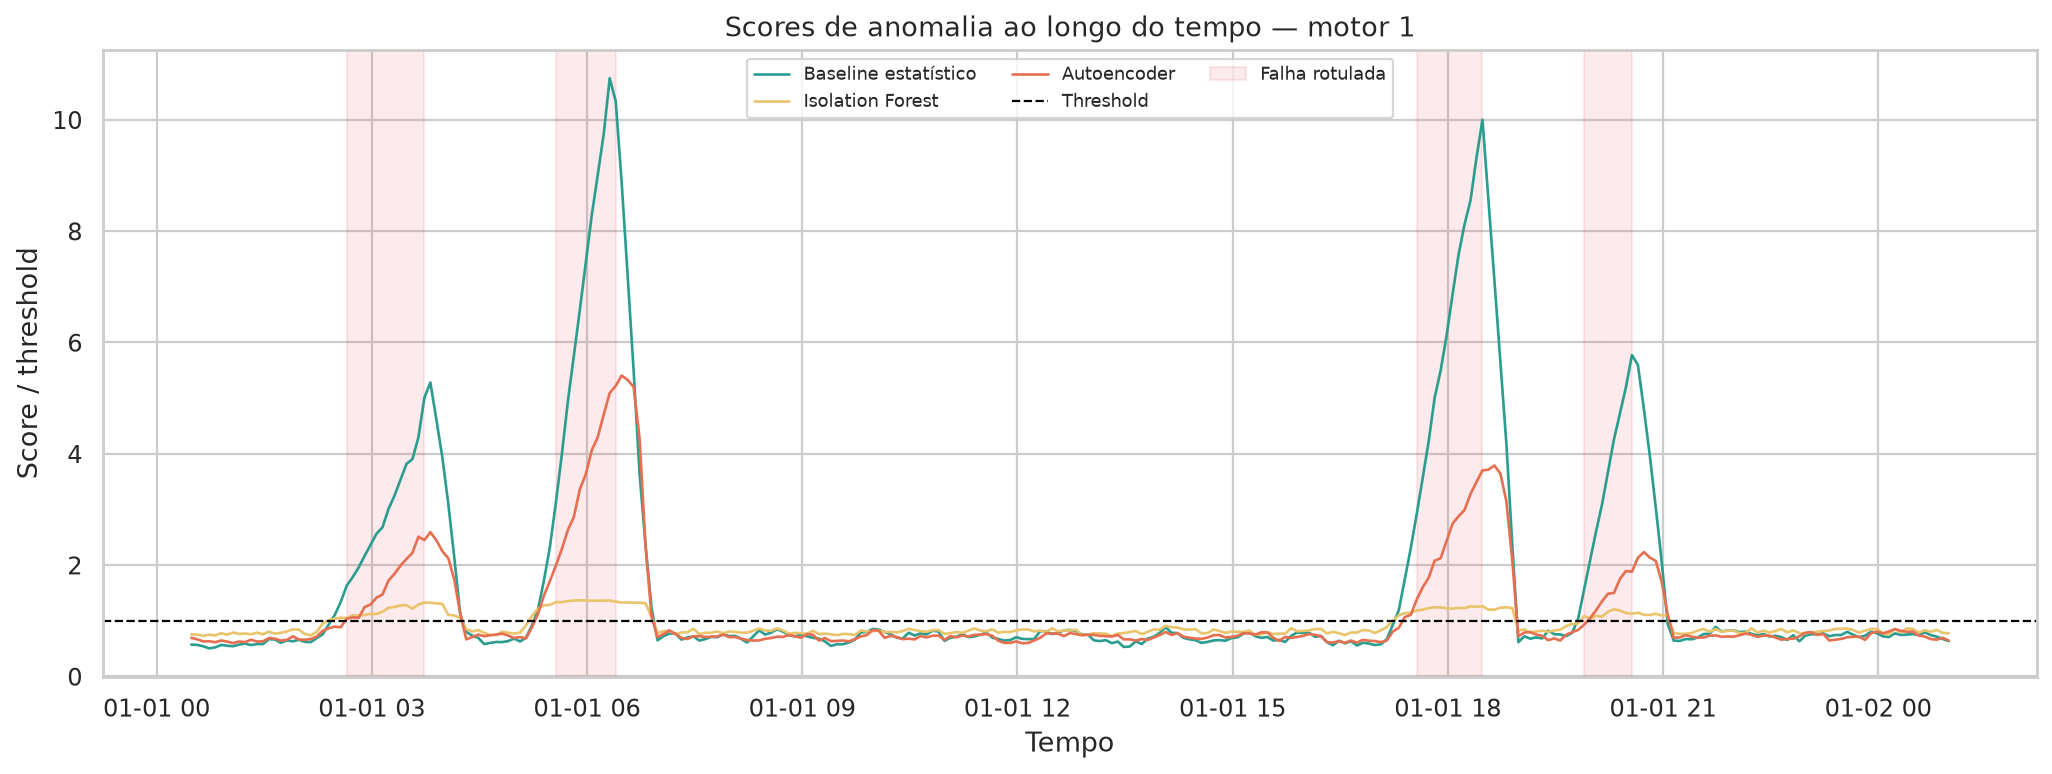

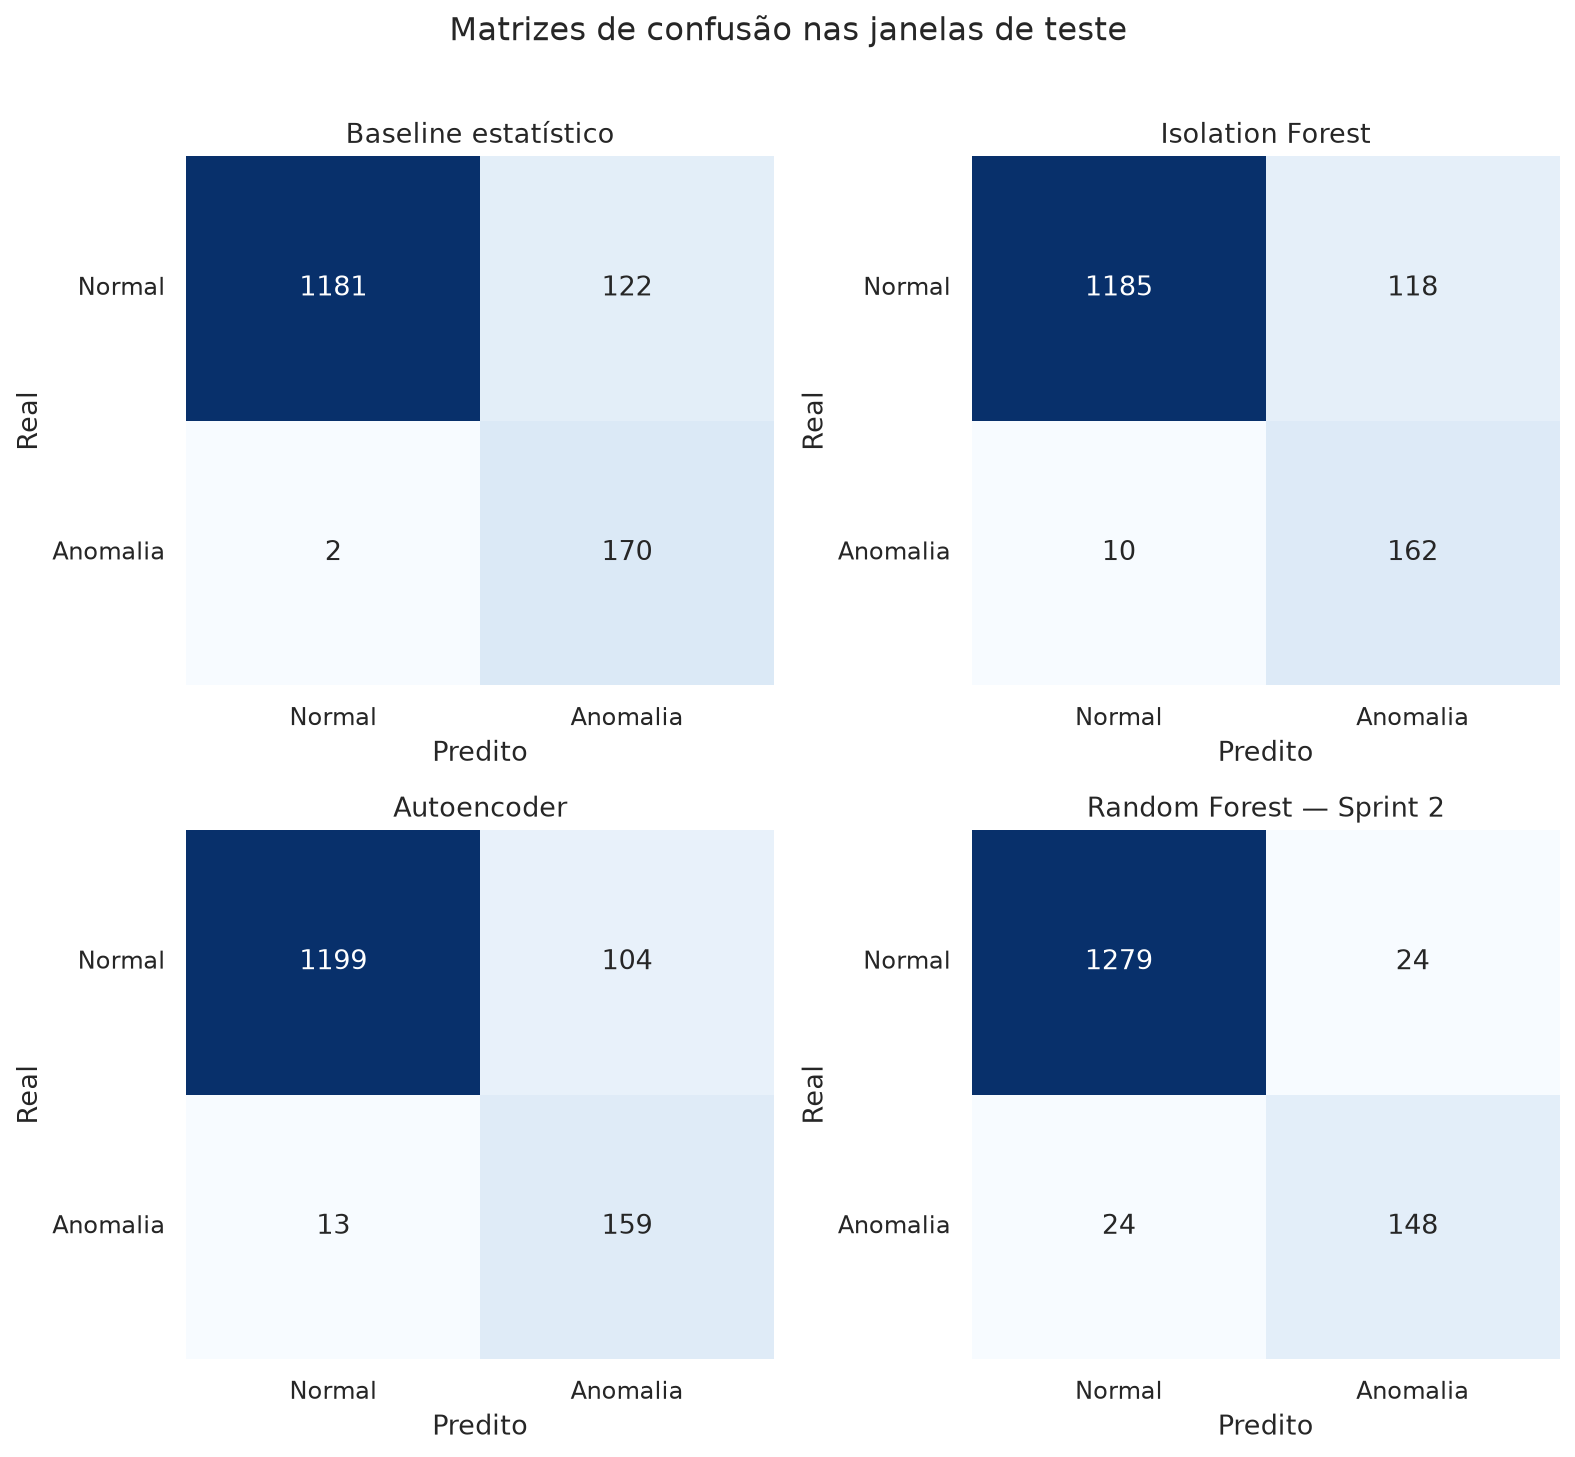

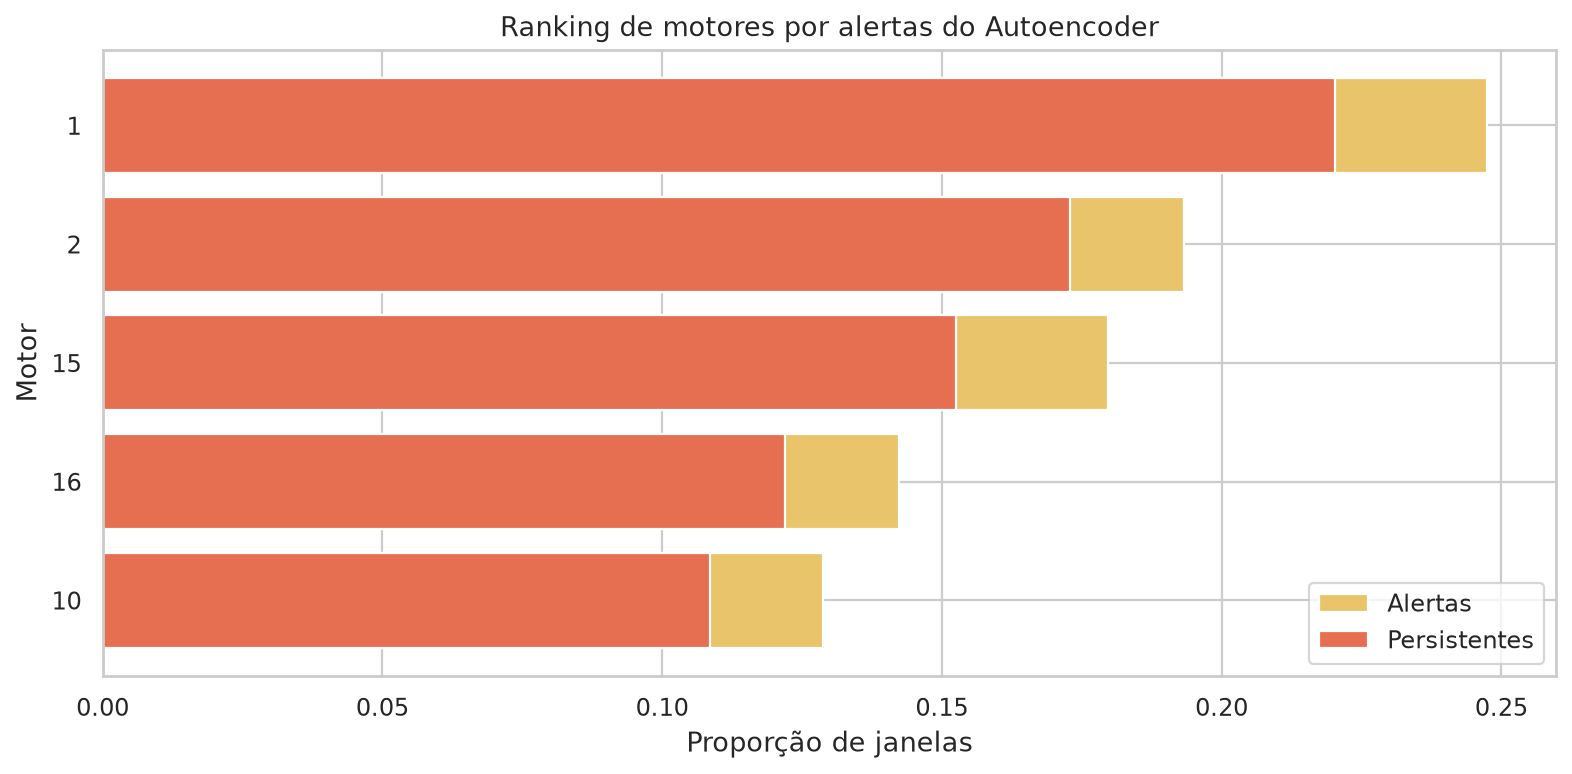

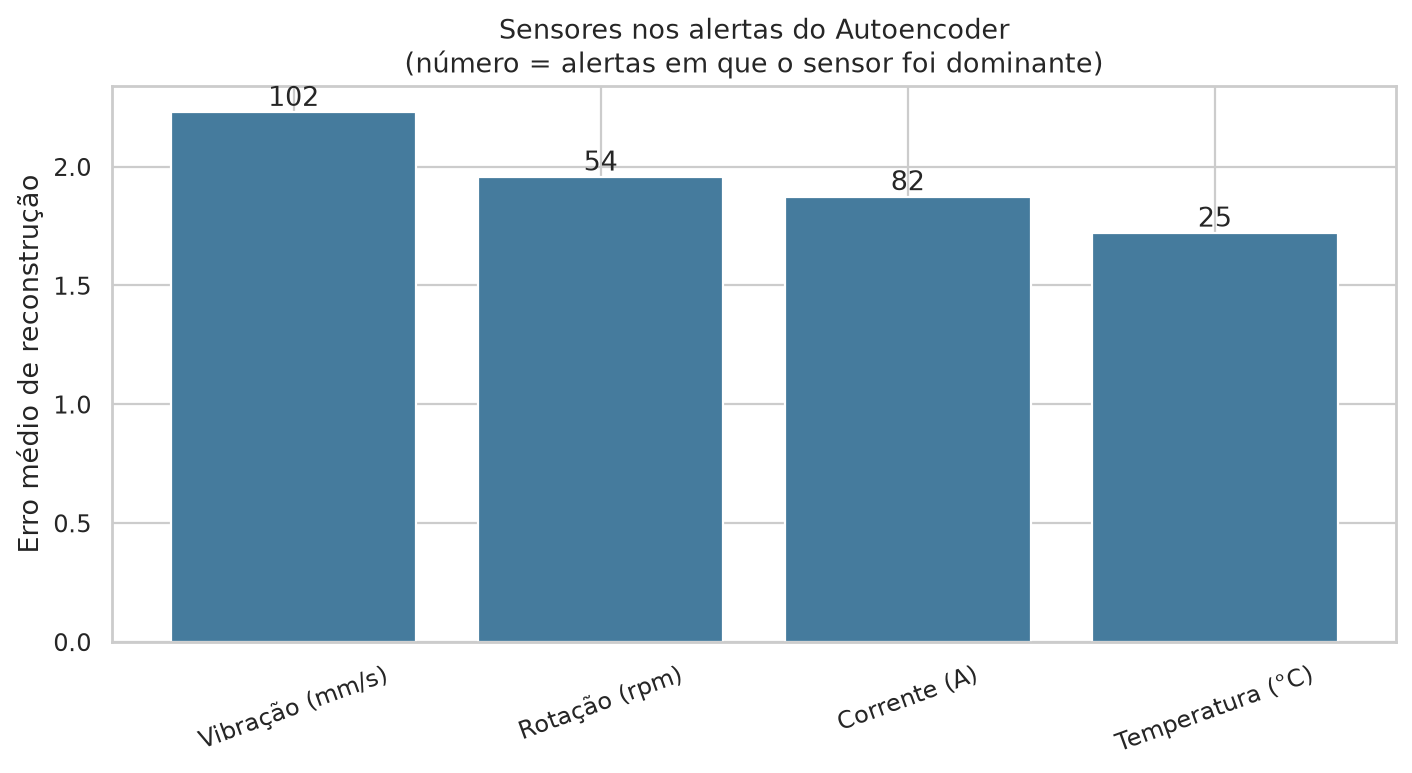

In [11]:
for name in [
    "s3_04_scores_tempo.png",
    "s3_05_matrizes_confusao.png",
    "s3_06_ranking_motores.png",
    "s3_07_contribuicao_sensores.png",
]:
    display(Image(filename=str(ROOT / "figuras" / name)))

## 11. Integração futura com agente conversacional

A função local abaixo produz um payload com score, severidade, persistência, sensores
dominantes e explicação. Um agente poderá responder perguntas como “por que o motor 1
está em alerta?”, preservando os números calculados pelo pipeline.

In [12]:
candidate = scored.query("partition == 'test'").sort_values("autoencoder_score").iloc[-1]
sensor_errors = {feature: candidate[f"ae_error_{feature}"] for feature in FEATURES}
build_agent_payload(
    motor_id=candidate.motor_id,
    timestamp=candidate.timestamp,
    score=candidate.autoencoder_score,
    threshold=candidate.autoencoder_threshold,
    persistent=candidate.autoencoder_persistent,
    sensor_errors=sensor_errors,
)

{'motor_id': 1,
 'timestamp': '2026-01-01T06:29:00',
 'anomaly_score': 5.142161020051012,
 'threshold': 0.9512501159120564,
 'score_ratio': 5.405687667244823,
 'severity': 'high',
 'persistent': True,
 'dominant_sensors': ['rotacao_rpm', 'corrente_a'],
 'sensor_errors': {'rotacao_rpm': 7.379518208764859,
  'vibracao_mm_s': 3.0882260286673273,
  'temperatura_c': 4.404950092808945,
  'corrente_a': 5.695949749962918},
 'explanation': 'Desvio persistente acima do baseline, com maior erro em rotacao_rpm, corrente_a. Recomenda-se inspeção técnica; o alerta não comprova a causa.'}

## 12. Código e organização

O script `src/run_sprint3.py` recria modelo, métricas, CSVs, relatório e figuras.
A suíte pytest protege partições, calibração, janelas, thresholds, persistência, eventos,
comparação e payload conversacional. Os artefatos versionados permitem auditoria sem
executar novamente o treino.

### Limitações finais

- base sintética e horizonte curto;
- primeiras 30 leituras assumidas como comissionamento saudável;
- threshold precisa ser recalibrado em dados reais;
- alerta pré-rótulo pode representar degradação emergente ou falso positivo;
- sensor dominante não equivale à causa raiz.

In [13]:
artifact_paths = [
    ROOT / "models" / "modelo_anomalias.joblib",
    ROOT / "models" / "anomaly_metrics.json",
    ROOT / "results" / "anomaly_scores.csv",
    ROOT / "docs" / "sprint3_report.md",
]
pd.DataFrame({"artefato": [str(path.relative_to(ROOT)) for path in artifact_paths], "existe": [path.exists() for path in artifact_paths]})

,artefato,existe
0,models/modelo_anomalias.joblib,True
1,models/anomaly_metrics.json,True
2,results/anomaly_scores.csv,True
3,docs/sprint3_report.md,True
